# SKKU 2024 Challenge
## Quantum State Tomography

In [ ]:
import numpy as np
import qiskit
from qiskit_aer import Aer

In [ ]:
## utils.py
backend = Aer.get_backend("aer_simulator")
def create_1q_target_circuit(qc_data):
    qc = qiskit.QuantumCircuit(1)
    qc.ry(qc_data[0],0)
    qc.rz(qc_data[1],0)
    return qc

def create_2q_target_circuit(qc_data):
    qc = qiskit.QuantumCircuit(2)
    for i in range(2):
        qc.ry(qc_data[2*i],i)
        qc.rz(qc_data[2*i+1],i)
    qc.cx(0,1)
    qc.rz(qc_data[4],1)
    qc.cx(0,1)
    for i in range(2):
        qc.ry(qc_data[2*i+5],i)
        qc.rz(qc_data[2*i+6],i)
    return qc

backend2 = Aer.get_backend("statevector_simulator")
def give_score(U_hidden, U_gen):
    qc = U_hidden.compose(U_gen.inverse())
    result = backend2.run(qc).result()
    score = result.get_statevector()[0]
    return np.abs(score)

## TODO : make error handler
def MeasurementResultHandler(result:dict, num_qubits:int, num_shots:int=100):
	for i in range(2**num_qubits):
		result[format(i,"#x")] = np.array(result[format(i,"#x")]/num_shots) if result.get(format(i,"#x")) else np.array(0)
	return result
   

def generate_clifford_circ(num_qubits, depth):
    U_hidden = qiskit.QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        U_hidden.h(i)
    count = 0
    s1s2 = {-1,-1}
    while(count < depth):
        site_i = int(np.random.rand()*num_qubits)
        site_j = int(np.random.rand()*num_qubits)
        if(site_i == site_j or {site_i, site_j} == s1s2):
            continue
        print(site_i, site_j, count)
        count += 1
        s1s2 = {site_i, site_j}
        U_hidden.cz(site_i, site_j)
    return U_hidden

# Phase 3
# Check whether b_i ⨁_{j∈(i,j)} b_j=0.
def xor_bits_at_positions(nums, positions, base_location):
	for num in nums:    
		# Start with 0 for XOR accumulation
		result = (num >> base_location) & 1
		
		# XOR each specified bit position
		for pos in positions:
			# Extract the bit at the current position and XOR it with the result
			result ^= (num >> pos) & 1
		
		if result == 0:
			continue
		else:
			return False

	return True

# Given graph G genreate graph state.
#∣ψ⟩= ∏ _{(i,j)∈G} CZ(i,j) H^{⊗n} ∣0⟩
def GraphState(num_qubits, graph):
	U_gen = qiskit.QuantumCircuit(num_qubits)
	for i in range(num_qubits):
		U_gen.h(i)

	for vertex in graph:
		temp = list(vertex)
		site_i = temp[0]
		site_j = temp[1]
		U_gen.cz(site_i, site_j)

	return U_gen

def low_depth(num_qubits):
    qc = qiskit.QuantumCircuit(num_qubits)
    for i in range(0, num_qubits-1, 2):
        params = np.random.rand(15)*2*np.pi
        qc.u(params[0], params[1], params[2],i)
        qc.u(params[3], params[4], params[5],i+1)
        qc.rxx(params[6],i,i+1)
        qc.ryy(params[7],i,i+1)
        qc.rzz(params[8],i,i+1)
        qc.u(params[9], params[10], params[11],i)
        qc.u(params[12], params[13], params[14],i+1)
        
    for j in range(1,num_qubits - (num_qubits +1)%2 ,2):
        params = np.random.rand(15)*2*np.pi
        qc.u(params[0], params[1], params[2],j)
        qc.u(params[3], params[4], params[5],j+1)
        qc.rxx(params[6],j,j+1)
        qc.ryy(params[7],j,j+1)
        qc.rzz(params[8],j,j+1)
        qc.u(params[9], params[10], params[11],j)
        qc.u(params[12], params[13], params[14],j+1)
    
    U_hidden = qc
    return U_hidden

### Problem 1

#### Part I

##### a)

In a given single qubit pure state can be written as:
$$
\ket{\psi} = a\ket{0} + b e^{i\theta} \ket{1}
$$
where $a, b, \theta$ are real parameter subject to $a^2 + b^2 =1$ and $0 \leq \theta < 2\pi$. 
In order to determine these three parameter, it requires at least three measurement. 

Our measurement is performed via POVM. There are detectors whose number is equal to the number of qubits. 
In this scenerio, we perform $z$-basis projection measurement. Therefore, the POVM becomes $\left\{ \ket{0}\bra{0}, \ket{1}\bra{1}\right\}$, each corresponds to the presense of signal or not. 
Let $\hat{m}_0, \hat{m}_1$ denote the estimated probability of occuring signals. 
We can add another operation $U$ before the measurement and after the computational stage(here, state preparation), we can perform measurement another POVM basis, $\left\{ U^{\dagger} \ket{0}\bra{0} U, U^{\dagger} \ket{1}\bra{1} U\right\}$.

In first measurement, to determine $a, b$, we can directly perform measurement without any unitary operation. That is $U^1 = I$, here. 
Then, we see:
$$
\begin{align}
	\hat{m}_0 &\simeq  \left| \bra{\psi}\ket{0} \right|^2 &= a^2 \\
	\hat{m}_1 &\simeq  \left| \bra{\psi}\ket{1} \right|^2 &= b^2 \\
\end{align}
$$
Therefore, we can estimate,
$$
\begin{align}
	a &= \sqrt{\hat{m}_0} \\
	b &= \sqrt{\hat{m}_1} \\
\end{align}
$$
On the other hand, we need two additional measurement. 
Here let $U_2 = H$, where $H$ is a hadamard gate.
$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
	1 & 1 \\
	1 & -1
\end{pmatrix}.
$$
Then, our POVM becomes $\left\{ \ket{+}\bra{+}, \ket{-}\bra{-}\right\}$ where $\ket{+}, \ket{-}$ are the eigenstate of Pauli-X matrix whose eigenvalue is $1,-1$ for each.
Here, let $\hat{m}_{+}, \hat{m}_{-}$ be the estimated probability of occuring signals.
$$
\begin{align}
	\hat{m}_{+} &\simeq  \left| \bra{\psi}\ket{+} \right|^2 &= \left| \frac{a + b e^{i\theta}}{2} \right|^2 &= \frac{1 + 2ab\cos\theta}{2}  \\
	\hat{m}_{-} &\simeq  \left| \bra{\psi}\ket{-} \right|^2 &= \left| \frac{a - b e^{i\theta}}{2} \right|^2 &= \frac{1 - 2ab\cos\theta}{2} 
\end{align}
$$
Or,
$$
\cos\theta = \frac{\hat{m}_{+} - \hat{m}_{-}}{2ab}
$$
Here, it is not enough yet. As there is a degree of freedom choosing a sign of $\sin\theta$. 
Finally, let $U_3 = S H$ where $S$ is S gate.
$$
S = \begin{pmatrix}
	1 & 0 \\
	0 & i 
\end{pmatrix}.
$$
Then our POVM becomes $\left\{ \ket{i}\bra{i}, \ket{-i}\bra{-i}\right\}$ where $\ket{i}, \ket{-i}$ are the eigenstate of Pauli-Y matrix whose eigenvalue is $1,-1$ for each.
Here, let $\hat{m}_{i}, \hat{m}_{-i}$ be the estimated probability of occuring signals.
$$
\begin{align}
	\hat{m}_{i} &\simeq  \left| \bra{\psi}\ket{i} \right|^2 &= \left| \frac{a + b e^{i(\theta + \frac{\pi}{2})}}{2} \right|^2 &= \frac{1 + 2ab\sin\theta}{2}  \\
	\hat{m}_{-i} &\simeq  \left| \bra{\psi}\ket{-i} \right|^2 &= \left| \frac{a - b e^{i\theta  + \frac{\pi}{2}}}{2} \right|^2 &= \frac{1 - 2ab\sin\theta}{2}  
\end{align}
$$
Or,
$$
\sin\theta = \frac{\hat{m}_{i} - \hat{m}_{-i}}{2ab}
$$

##### b)

Now, Let me explain how we reconstruct circuit parameter. 
In glance of action of $RY$ and $RZ$ gate, we see:
$$
RY(\phi_{y}) = 
\begin{pmatrix}
	\cos \frac{\phi_{y}}{2} & -\sin \frac{\phi_{y}}{2} \\
	\sin \frac{\phi_{y}}{2} & \cos \frac{\phi_{y}}{2}
\end{pmatrix}
$$
and 
$$
RZ(\phi_{z}) = 
\begin{pmatrix}
	1 & 0 \\
	0 & e^{i\phi_{z}}
\end{pmatrix}
$$
Therefore, we have:
$$
RZ(\phi_{z})RY(\phi_{y}) = \cos \frac{\phi_{y}}{2} \ket{0} + e^{i\phi_{z}} \sin \frac{\phi_{y}}{2} \ket{1} .
$$
Comparing this equation to the first given $\ket{\psi}$, we find $\phi_{y} = 2\arccos a$ with $\phi_{y} = 2\arcsin b$ and $\phi_{z} = \theta$.

In [ ]:
def SingleQubitQST(U_hidden, num_shots:int=100):
	hidden_circuit = U_hidden.copy()
	
	qc1 = qiskit.QuantumCircuit(1)
	circ1 = hidden_circuit.compose(qc1)
	circ1.measure_all()
	#print(circ1.draw())
	
	qc2 = qiskit.QuantumCircuit(1)
	qc2.h(0)
	circ2 = hidden_circuit.compose(qc2)
	circ2.measure_all()
	#print(circ2.draw())
	
	qc3 = qiskit.QuantumCircuit(1)
	qc3.s(0)
	qc3.h(0)
	circ3 = hidden_circuit.compose(qc3)
	circ3.measure_all()
	#print(circ3.draw())
	
	result1 = MeasurementResultHandler(backend.run(circ1, shots=num_shots).result().data()["counts"], 1, num_shots)
	result2 = MeasurementResultHandler(backend.run(circ2, shots=num_shots).result().data()["counts"], 1, num_shots)
	result3 = MeasurementResultHandler(backend.run(circ3, shots=num_shots).result().data()["counts"], 1, num_shots)

	m0 = result1.get("0x0"); m1 = result1.get("0x1")
	phi = np.arctan2(np.sqrt(m1), np.sqrt(m0))
	phi = phi if phi > 0 else phi + 2*np.pi
	statevector = np.array([np.cos(phi), np.sin(phi)], dtype=np.complex64)

	#print(np.cos(phi), np.sin(phi), np.cos(phi)**2, np.sin(phi)**2, m0, m1)

	m_p = result2.get("0x0"); m_m = result2.get("0x1")
	cos = (m_p - m_m)/(2*np.cos(phi)*np.sin(phi))
 
	m_pi = result3.get("0x0"); m_mi = result3.get("0x1")
	sin = (-m_pi + m_mi)/(2*np.cos(phi)*np.sin(phi))

	temp = np.array([cos, sin])

	cos = cos / np.linalg.norm(temp)
	sin = sin / np.linalg.norm(temp)
	print(circ1.draw())
	theta = np.arctan2(sin, cos)
	theta = theta if theta > 0 else theta + 2*np.pi
 
	statevector[1] *= np.exp(1j*theta)
	circuit_parameter = np.array([2*phi, theta])

	return statevector, circuit_parameter

def SingleQubitCircuit(statevector):
	cos = np.linalg.norm(statevector[0]); sin = np.linalg.norm(statevector[1])
	phi = np.arctan2(sin,cos)
	theta = (np.log(statevector[1]/np.linalg.norm(statevector[1]))*-1j).real
 
	U_gen = qiskit.QuantumCircuit(1)
	U_gen.ry(2*phi,0)
	U_gen.rz(theta,0)
 
	return U_gen

In [ ]:
random_vec = np.random.rand(2)*2*np.pi
U_hidden = create_1q_target_circuit(random_vec)
statevector, circuit_parameter = SingleQubitQST(U_hidden)
U_gen = SingleQubitCircuit(statevector)
#print(circuit_parameter)
give_score(U_hidden, U_gen)

#### Part II

##### a)

In a given single qubit pure state can be written as:
$$
\ket{\psi} = a\ket{00} + b \ket{01} + c \ket{10} + d\ket{11}
$$
where $a$ is a real posivive number $b, c$ and $d$ are complex numbers subject to $a^2 + b^2 + c^2 + d^2 =1$ without loss of generality.
If the parameters are subjected to real numbers, it seems sufficient to idenify all the parameters $a, b, c$ and $d$ with running two circuits. 
First, we run circuit without any additional operation, $U=I$. 
Then our POVM bases are $\left\{ \ket{00}\bra{00}, \ket{01}\bra{01}, \ket{10}\bra{10}, \ket{11}\bra{11} \right\}$, which directly reproduce $a^2 , b^2 , c^2$ and $d^2$.
That is,
$$
\begin{align}
	\hat{m}_{00} &\simeq \left| \bra{\psi}\ket{00} \right|^2 &= a^2 \\ 
	\hat{m}_{01} &\simeq \left| \bra{\psi}\ket{01} \right|^2 &= b^2 \\ 
	\hat{m}_{10} &\simeq \left| \bra{\psi}\ket{10} \right|^2 &= c^2 \\ 
	\hat{m}_{11} &\simeq \left| \bra{\psi}\ket{11} \right|^2 &= d^2  
\end{align}
$$
where $\hat{m}_{00}, \hat{m}_{01}, \hat{m}_{10}, \hat{m}_{11}$ are the estimated probability from the measurement outcome, $\left\{ \ket{00}\bra{00}, \ket{01}\bra{01}, \ket{10}\bra{10}, \ket{11}\bra{11} \right\}$.
Next, we can add Hadamard operation both qubits, then the resulting POVM basis are $\left\{ \ket{++}\bra{++}, \ket{+-}\bra{+-}, \ket{-+}\bra{-+}, \ket{--}\bra{--} \right\}$.
Then, 
$$
\begin{align}
	\hat{m}_{++} &\simeq \left| \bra{\psi}\ket{++} \right|^2 &= \frac{(a+b+c+d)^2}{4} \\ 
	\hat{m}_{+-} &\simeq \left| \bra{\psi}\ket{+-} \right|^2 &= \frac{(a-b+c-d)^2}{4} \\ 
	\hat{m}_{-+} &\simeq \left| \bra{\psi}\ket{-+} \right|^2 &= \frac{(a+b-c-d)^2}{4} \\ 
	\hat{m}_{--} &\simeq \left| \bra{\psi}\ket{++} \right|^2 &= \frac{(a-b-c+d)^2}{4}  
\end{align}
$$
This results in the following equation:
$$
\begin{align}
	a+b+c+d &= \pm 2\sqrt{\hat{m}_{++}} \\ 
	a-b+c-d &= \pm 2\sqrt{\hat{m}_{+-}} \\ 
	a+b-c-d &= \pm 2\sqrt{\hat{m}_{-+}} \\ 
	a-b-c+d &= \pm 2\sqrt{\hat{m}_{--}} 
\end{align}
$$

##### b)

In a given single qubit pure state can be written as:
$$
\ket{\psi} = a\ket{00} + b e^{i\theta_{b}} \ket{01} + c e^{i\theta_{c}} \ket{10} + d e^{i\theta_{b}} \ket{11}
$$
where $a, b, c$ and $d$ are real posivive numbers $\theta_b , \theta_c , \theta_d$ are real numbers subject to $0 \le \theta_{b} , \theta_{c} , \theta_{d} <2\pi $ without loss of generality.
If the parameters are subjected to real numbers, it seems sufficient to idenify all the parameters $a, b, c$ and $d$ with running two circuits. 
First, we run circuit without any additional operation, $U=I$. 
Then our POVM bases are $\left\{ \ket{00}\bra{00}, \ket{01}\bra{01}, \ket{10}\bra{10}, \ket{11}\bra{11} \right\}$, which directly reproduce $a^2 , b^2 , c^2$ and $d^2$.
That is,
$$
\begin{align}
	\hat{m}_{00} &\simeq \left| \bra{\psi}\ket{00} \right|^2 &= a^2 \\ 
	\hat{m}_{01} &\simeq \left| \bra{\psi}\ket{01} \right|^2 &= b^2 \\ 
	\hat{m}_{10} &\simeq \left| \bra{\psi}\ket{10} \right|^2 &= c^2 \\ 
	\hat{m}_{11} &\simeq \left| \bra{\psi}\ket{11} \right|^2 &= d^2  
\end{align}
$$

Next, using Hadamard gate on first qubit, we have:
$$
\begin{align}
	\hat{m}_{+0} &\simeq \left| \bra{\psi}\ket{+0} \right|^2 &= \left| \frac{a+c e^{i\theta_c}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{+1} &\simeq \left| \bra{\psi}\ket{+1} \right|^2 &= \left| \frac{b e^{i\theta_b}+d e^{i\theta_d}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-0} &\simeq \left| \bra{\psi}\ket{-0} \right|^2 &= \left| \frac{a-c e^{i\theta_c}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-1} &\simeq \left| \bra{\psi}\ket{-1} \right|^2 &= \left| \frac{b e^{i\theta_b}-d e^{i\theta_d}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, we see:
$$
\begin{align}
	\cos\theta_{c} &= \frac{\hat{m}_{+0} - \hat{m}_{-0}}{2}\\
	\cos(\theta_{b} - \theta_{d}) &= \frac{\hat{m}_{+1} - \hat{m}_{-1}}{2}\\
\end{align}
$$
With Hadamard gate and S gate on first qubit, we see:
$$
\begin{align}
	\hat{m}_{i0} &\simeq \left| \bra{\psi}\ket{i0} \right|^2 &= \left| \frac{a+c e^{i\theta_c + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{i1} &\simeq \left| \bra{\psi}\ket{i1} \right|^2 &= \left| \frac{b e^{i\theta_b}+d e^{i\theta_d + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-i0} &\simeq \left| \bra{\psi}\ket{-i0} \right|^2 &= \left| \frac{a-c e^{i\theta_c - \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{-i1} &\simeq \left| \bra{\psi}\ket{-i1} \right|^2 &= \left| \frac{b e^{i\theta_b}-d e^{i\theta_d - \frac{\pi}{2}}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, 
$$
\begin{align}
	\sin\theta_{c} &= \frac{\hat{m}_{+0} - \hat{m}_{-0}}{2}\\
	\sin(\theta_{b} - \theta_{d}) &= \frac{\hat{m}_{+1} - \hat{m}_{-1}}{2}\\
\end{align}
$$
Also, using Hadamard gate on second qubit, we have:
$$
\begin{align}
	\hat{m}_{0+} &\simeq \left| \bra{\psi}\ket{0+} \right|^2 &= \left| \frac{a+b e^{i\theta_b}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{0-} &\simeq \left| \bra{\psi}\ket{0-} \right|^2 &= \left| \frac{a -b e^{i\theta_b}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{1+} &\simeq \left| \bra{\psi}\ket{1+} \right|^2 &= \left| \frac{c e^{i\theta_c} +d e^{i\theta_d}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{1-} &\simeq \left| \bra{\psi}\ket{1-} \right|^2 &= \left| \frac{c e^{i\theta_c}- d e^{i\theta_d}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, we see:
$$
\begin{align}
	\cos\theta_{b} &= \frac{\hat{m}_{0+} - \hat{m}_{0-}}{2}\\
	\cos(\theta_{c} - \theta_{d}) &= \frac{\hat{m}_{1+} - \hat{m}_{1-}}{2}\\
\end{align}
$$
With Hadamard gate and S gate on second qubit, we see:
$$
\begin{align}
	\hat{m}_{0i} &\simeq \left| \bra{\psi}\ket{0i} \right|^2 &= \left| \frac{a+b e^{i\theta_b + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{1i} &\simeq \left| \bra{\psi}\ket{1i} \right|^2 &= \left| \frac{a+b e^{i\theta_b + \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{0-i} &\simeq \left| \bra{\psi}\ket{0-i} \right|^2 &= \left| \frac{c e^{i\theta_c} +d e^{i\theta_d - \frac{\pi}{2}}}{\sqrt{2}}\right|^2 \\ 
	\hat{m}_{0-i} &\simeq \left| \bra{\psi}\ket{0-i} \right|^2 &= \left| \frac{c e^{i\theta_c}- d e^{i\theta_d - \frac{\pi}{2}}}{\sqrt{2}}\right|^2
\end{align}
$$
Then, 
$$
\begin{align}
	\sin\theta_{b} &= \frac{\hat{m}_{+0} - \hat{m}_{-0}}{2}\\
	\sin(\theta_{c} - \theta_{d}) &= \frac{\hat{m}_{+1} - \hat{m}_{-1}}{2}\\
\end{align}
$$
Now we can determine $\theta_{b}, \theta_{c}$ $\theta_{d}$.

In [616]:
def TwoQubitQST(U_hidden, num_shots:int=100):
	hidden_circuit = U_hidden.copy()
	
	qc1 = qiskit.QuantumCircuit(2)
	circ1 = hidden_circuit.compose(qc1)
	circ1.measure_all()
	#print(circ1.draw())
	result1 = MeasurementResultHandler(backend.run(circ1, shots=num_shots).result().data()["counts"], 2, num_shots)
	m_00 = result1.get("0x0"); m_01 = result1.get("0x1"); m_10 = result1.get("0x2"); m_11 = result1.get("0x3") 
	if m_00 == 1:
		return np.array([1,0,0,0], dtype=np.complex64)
	if m_01 == 1:
		return np.array([0,1,0,0], dtype=np.complex64)
	if m_10 == 1:
		return np.array([0,0,1,0], dtype=np.complex64)
	if m_11 == 1:
		return np.array([0,0,0,1], dtype=np.complex64)
	
	qc2 = qiskit.QuantumCircuit(2)
	if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
		qc2.cx(0,1) # swap b, d

	qc2.h(0)
	circ2 = hidden_circuit.compose(qc2)
	circ2.measure_all()
	#print(circ2.draw())
	
	qc3 = qiskit.QuantumCircuit(2)
	if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
		qc3.cx(0,1) # swap b, d
	qc3.s(0)
	qc3.h(0)
	circ3 = hidden_circuit.compose(qc3)
	circ3.measure_all()
	#print(circ3.draw())

	qc4 = qiskit.QuantumCircuit(2)
	if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
		qc4.cx(0,1) # swap b, d
	qc4.h(1)
	circ4 = hidden_circuit.compose(qc4)
	circ4.measure_all()
	#print(circ4.draw())
	
	qc5 = qiskit.QuantumCircuit(2)
	if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
		qc5.cx(0,1) # swap b, d
	qc5.s(1)
	qc5.h(1)
	circ5 = hidden_circuit.compose(qc5)
	circ5.measure_all()
	#print(circ5.draw())
	
	result2 = MeasurementResultHandler(backend.run(circ2, shots=num_shots).result().data()["counts"], 2, num_shots)
	result3 = MeasurementResultHandler(backend.run(circ3, shots=num_shots).result().data()["counts"], 2, num_shots)
	result4 = MeasurementResultHandler(backend.run(circ4, shots=num_shots).result().data()["counts"], 2, num_shots)
	result5 = MeasurementResultHandler(backend.run(circ5, shots=num_shots).result().data()["counts"], 2, num_shots)

	a = np.sqrt(m_00); b = np.sqrt(m_01); c = np.sqrt(m_10); d = np.sqrt(m_11)
	if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
		d = np.sqrt(m_01); b = np.sqrt(m_11)
		

	statevector = np.array([a,b,c,d], dtype=np.complex64)
	theta_01 = 0; theta_10 = 0; theta_11 = 0

	executing_Eq = {i for i in range(1,9)}
	related_Eq = {
		"a" : {1,3,5,7},
		"b" : {1,3,6,8},
		"c" : {2,4,5,7},
		"d" : {2,4,6,8}
	}
	if a == 0:
		executing_Eq-= related_Eq["a"]
	if b == 0:
		executing_Eq-= related_Eq["b"]
	if c == 0:
		executing_Eq-= related_Eq["c"]
	if d == 0:
		executing_Eq-= related_Eq["d"]

	m_0p = result2.get("0x0"); m_0m = result2.get("0x1"); m_1p = result2.get("0x2"); m_1m = result2.get("0x3") 
	m_0P = result3.get("0x0"); m_0M = result3.get("0x1"); m_1P = result3.get("0x2"); m_1M = result3.get("0x3") 
	m_p0 = result4.get("0x0"); m_p1 = result4.get("0x1"); m_m0 = result4.get("0x2"); m_m1 = result4.get("0x3") 
	m_P0 = result5.get("0x0"); m_P1 = result5.get("0x1"); m_M0 = result5.get("0x2"); m_M1 = result5.get("0x3") 

	if 1 in executing_Eq:
		# eq 1.
		cos_00_01 = (m_0p - m_0m) / (2*a*b)
	if 2 in executing_Eq:
		# eq 2.
		cos_10_11 = (m_1p - m_1m) / (2*c*d)

	if 3 in executing_Eq:
		# eq 3.
		sin_00_01 = (-m_0P + m_0M) / (2*a*b)
	if 4 in executing_Eq:
		# eq 4.
		sin_10_11 = (m_1P - m_1M) / (2*c*d)

	if 5 in executing_Eq:
		# eq 5.
		cos_00_10 = (m_p0 - m_m0) / (2*a*c)
	if 6 in executing_Eq:
		# eq 6.
		cos_01_11 = (m_p1 - m_m1) / (2*b*d)

	if 7 in executing_Eq:
		# eq 7.
		sin_00_10 = (-m_P0 + m_M0) / (2*a*c)
	if 8 in executing_Eq:
		# eq 8.
		sin_01_11 = (m_P1 - m_M1) / (2*b*d)


	if a != 0:
		if b != 0:
			theta_01 = np.arctan2(sin_00_01, cos_00_01)
			theta_01 = theta_01 if theta_01 >= 0 else theta_01 + 2*np.pi
			if c != 0:
				theta_10 = np.arctan2(sin_00_10, cos_00_10)
				theta_10 = theta_10 if theta_10 >= 0 else theta_10 + 2*np.pi
				if d != 0:
					if b < c:
        
						theta_10_11= np.arctan2(sin_10_11, cos_10_11)
						theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
						
						theta_11 = theta_10 - theta_10_11
						theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
					else:
						theta_01_11= np.arctan2(sin_01_11, cos_01_11)
						theta_01_11 = theta_01_11 if theta_01_11 >= 0 else theta_01_11 + 2*np.pi
						
						theta_11 = theta_01 - theta_01_11
						theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
     
				#else:
			else:
				if d!=0:
					theta_01_11= np.arctan2(sin_01_11, cos_01_11)
					theta_01_11 = theta_01_11 if theta_01_11 >= 0 else theta_01_11 + 2*np.pi
					
					theta_11 = theta_01 - theta_01_11
					theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
				#else:
		else:
			if c != 0:
				theta_10 = np.arctan2(sin_00_10, cos_00_10)
				theta_10 = theta_10 if theta_10 >= 0 else theta_10 + 2*np.pi
     
				if d != 0:
					theta_10_11= np.arctan2(sin_10_11, cos_10_11)
					theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
					
					theta_11 = theta_10 - theta_10_11
					theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
			#else:
					
	else:
		if b != 0:
			if c != 0 and d != 0:
				theta_01_11= np.arctan2(sin_01_11, cos_01_11)
				theta_01_11 = theta_01_11 if theta_01_11 >= 0 else theta_01_11 + 2*np.pi
				
				theta_11 = - theta_01_11
				theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
    
				theta_10_11= np.arctan2(sin_10_11, cos_10_11)
				theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
				
				theta_10 = theta_11 + theta_10_11
				theta_10 = theta_10 if theta_10 >= 0 else theta_10 + 2*np.pi
    
		else:
			theta_10_11= np.arctan2(sin_10_11, cos_10_11)
			theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
			
			theta_11 = - theta_10_11
			theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
		
	statevector[1] *= np.exp(1j*theta_01)
	statevector[2] *= np.exp(1j*theta_10)
	statevector[3] *= np.exp(1j*theta_11)
 		
	if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
		statevector[1], statevector[3] = statevector[3], statevector[1]
 
	return statevector    

In [868]:
def TwoQubitCircuit(statevector, eps=1e-3):

	# Schmidt decomposition
	# TODO : error handler when there is only one d
	a_jk = statevector.reshape(2,2)
	u, d, vh = np.linalg.svd(a_jk)
	d = d.astype(np.complex64)
 
 
	if d[0] == 0 or d[1] == 0:
		idx = 0 if d[1] == 0 else 1
  
		e2_1 = u[:,idx]
		e1_1 = vh[idx,:]
  
		# Ensure e2_1[0], ... be real, positive number
		phase1 = e2_1[0] / np.linalg.norm(e2_1[0]) if np.linalg.norm(e2_1[0]) != 0 else 1; phase2 = e1_1[0] / np.linalg.norm(e1_1[0]) if np.linalg.norm(e1_1[0]) != 0 else 1

		theta_1 = 2*np.arccos(e1_1[0].real)
		phi_1 = (-1j * np.log(e1_1[1]/np.sin(theta_1/2))).real if np.abs(np.sin(theta_1/2)) > eps else 0

		theta_2 = 2*np.arccos(e2_1[0].real)
		phi_2 = (-1j * np.log(e2_1[1]/np.sin(theta_2/2))).real if np.abs(np.sin(theta_2/2)) > eps else 0
		
		U_gen = qiskit.QuantumCircuit(2)
		U_gen.ry(theta_1,0)
		U_gen.rz(phi_1,0)
		U_gen.ry(theta_2,1)
		U_gen.rz(phi_2,1)

		return U_gen
	
	else:
		e2_1 = u[:,0]; e2_2 = u[:,1]
		e1_1 = vh[0,:]; e1_2 = vh[1,:]
		# Ensure e2_1[0], ... be real, positive number
		phase1 = e2_1[0] / np.linalg.norm(e2_1[0]) if np.linalg.norm(e2_1[0]) != 0 else 1; phase2 = e1_1[0] / np.linalg.norm(e1_1[0]) if np.linalg.norm(e1_1[0]) != 0 else 1
		d[0] *= phase1 * phase2
		e2_1 /= phase1; e1_1 /= phase2
		phase1 = e2_2[0] / np.linalg.norm(e2_2[0]) if np.linalg.norm(e2_2[0]) != 0 else 1; phase2 = e1_2[0] / np.linalg.norm(e1_2[0]) if np.linalg.norm(e1_2[0]) != 0 else 1
		d[1] *= phase1 * phase2
		e2_2 /= phase1; e1_2 /= phase2

		phase_d = d[0] / np.linalg.norm(d[0])
		d /= phase_d

		theta = 2 * np.arccos(d[0].real)
		phi = (-1j*np.log(d[1]/np.sin(theta/2))).real if np.abs(np.sin(theta/2)) != 0 else 0

		theta_1 = 2*np.arccos(e1_1[0].real)
		phi_1 = (-1j * np.log(e1_1[1]/np.sin(theta_1/2))).real if np.abs(np.sin(theta_1/2)) != 0 else 0

		theta_2 = 2*np.arccos(e2_1[0].real)
		phi_2 = (-1j * np.log(e2_1[1]/np.sin(theta_2/2))).real if np.abs(np.sin(theta_2/2)) != 0 else 0
		
		U_gen = qiskit.QuantumCircuit(2)
		U_gen.ry(theta,0)
		U_gen.rz(phi,0)
		U_gen.cx(0,1)
		U_gen.ry(theta_1,0)
		U_gen.rz(phi_1,0)
		U_gen.ry(theta_2,1)
		U_gen.rz(phi_2,1)

		return U_gen

In [869]:
import scipy
def test(vec):
	X = np.array([
		[0,1],
		[1,0]
	], dtype=np.complex64)
	Y = np.array([
		[0,-1j],
		[1j,0]
	], dtype=np.complex64)
	Z = np.array([
		[1,0],
		[0,-1]
	], dtype=np.complex64)
	RY = lambda a : scipy.linalg.expm(-1j*Y*a/2)
	RZ = lambda a : scipy.linalg.expm(-1j*Z*a/2)
	temp = np.zeros([2,2])
	zero = temp.copy()
	ones = temp.copy()
	zero[0,0] = 1
	ones[1,1] = 1
	CX = np.kron(np.eye(2), zero) + np.kron(X, ones)
	
	state = np.kron(RZ(vec[8]) @ RY(vec[7]) , RZ(vec[6]) @ RY(vec[5])) @ CX @ np.kron(RZ(vec[4]),np.eye(2, dtype=np.complex64)) @ CX @ np.kron(RZ(vec[3]) @ RY(vec[2]) , RZ(vec[1]) @ RY(vec[0]))
	phase = state[0,0] / np.linalg.norm(state[0,0])	
	state = state[:, 0]/phase
 
	theta_b =(-1j* np.log(state[1]/np.linalg.norm(state[1]))).real
	theta_c =(-1j* np.log(state[2]/np.linalg.norm(state[2]))).real
	theta_d =(-1j* np.log(state[3]/np.linalg.norm(state[3]))).real
 
	theta_b = theta_b if theta_b > 0 else theta_b + 2*np.pi
	theta_c = theta_c if theta_c > 0 else theta_c + 2*np.pi
	theta_d = theta_d if theta_d > 0 else theta_d + 2*np.pi
 
	#print("real", (state*state.conj()).real)
	print(theta_b, theta_c, theta_d)
	return state

In [870]:
random_vec = np.random.rand(9)*np.pi*2
np.set_printoptions(linewidth=np.inf, threshold=5)
U_hidden = create_2q_target_circuit(random_vec)
statevector = TwoQubitQST(U_hidden)
U_gen = TwoQubitCircuit(statevector)
give_score(U_hidden, U_gen) > 0.95

AttributeError: 'qiskit._accelerate.circuit.CircuitInstruction' object has no attribute 'get'

In [ ]:
temp = U_hidden.compose(U_gen.inverse())
temp.draw(output="mpl")

#### Part III

### Problem 2

##### a)
Positive eigenvalue

In [ ]:
import itertools

def GraphStateQST(U_hidden, num_shots=100):
	hidden_circuit = U_hidden.copy()
	num_qubits = len(U_hidden.qubits)
	graph = [] # G: set of (i,j)
	for i in range(num_qubits):
		# Phase 1
		qc = qiskit.QuantumCircuit(num_qubits)
		qc.h(i)
		circ = hidden_circuit.compose(qc)
		circ.measure_all()

		# Phase 2
		# Extract bit string
		result = backend.run(circ, shots=num_shots).result().data()["counts"]
		result = [int(i,16) for i in result.keys()]

		# Phase 3
		# Generating possible set of (i,j)
		qubit_index = [idx for idx in range(num_qubits)]
		qubit_index.pop(i)
		
		for k in range(1, num_qubits):
			for comb in itertools.combinations(qubit_index, k):
				isConnected = xor_bits_at_positions(result, comb, i)
				if isConnected:
					for edge in comb:
						graph.append({i, edge}) if {i, edge} not in graph else None
	
	return graph

In [ ]:
num_qubits = 19
depth = 80
U_hidden = generate_clifford_circ(num_qubits, depth)
graph = GraphStateQST(U_hidden)
U_gen = GraphState(num_qubits, graph)

In [ ]:
give_score(U_hidden, U_gen)

#### Problem 3

In [976]:
def LowDepthQST(U_hidden, num_shots=100):
    hidden_circuit = U_hidden.copy()
    
    num_qubits = len(hidden_circuit.qubits)
    target_set = GenerateTargetQubitSet(num_qubits)
    circuits = [GenerateMeasurementCircuits(hidden_circuit, target_set[idx]) for idx in range(4)]
    
    # Run circuit
    measurement_outcomes_phase = {} # { 0 : [measurement_outcomes_1, measurement_outcomes_2, ..., measurement_outcomes_5] }
    for phase in range(4):
        temp = []
        for circ in circuits[phase]: # 5 circuits
            measurement_outcomes = backend.run(circ, shots=num_shots).result().data()["counts"]
            measurement_outcomes = MeasurementResultHandler(measurement_outcomes, num_qubits=2*len(target_set[phase]))
            temp.append(measurement_outcomes)
        measurement_outcomes_phase[phase] = temp

    # Perform Two-qubit QST
    # Split measurement result
    twoQubitMeasurement = {} # {(0,1) : [{"0x0" : ~ ,... }, {"0x0" : ~ ,... }, ...] ], (1,2) : ~ , ... }
    for key, value in measurement_outcomes_phase.items():
        splitedOutcomes = SplitMeasurementResult(value, target_set[key])
        twoQubitMeasurement.update(splitedOutcomes)

    # Perform Two-qubit state measurement for each target state. 
    twoQubitStateVectors = {}
    for key, value in twoQubitMeasurement.items():
        twoQubitStateVectors[key] = TwoQubitQST2(value)
        
    # Generate U_gen
    U_gen = qiskit.QuantumCircuit(num_qubits)
    # First Layer Circuit
    upper_idx = (num_qubits-1) //2 if num_qubits %2 ==1 else (num_qubits-1) //2+1
    firstLayerQubitIndex = [(2*i, 2*i+1) for i in range(upper_idx)]
    # Generate and Append First Layer Circuit

    for qubit_pair in firstLayerQubitIndex:
        two_U_gen = qiskit.QuantumCircuit(2)
        two_U_gen = TwoQubitCircuit(twoQubitStateVectors.get(qubit_pair))
        U_gen = U_gen.compose(two_U_gen, qubits=list(qubit_pair))
    
    # Second Layer Circuit
    upper_idx = (num_qubits-2) //2 if num_qubits % 2 == 0 else (num_qubits-2) //2 + 1
    secondLayerQubitIndex = [(2*i+1, 2*i+2) for i in range(upper_idx)]
    secondLayerQubitNeighborIndex = [
                                     [(2*i, 2*i+1),(2*i+2, 2*i+3)] if 2*i +3 < num_qubits else [(2*i, 2*i+1),] 
                                     for i in range(upper_idx)
                                     ]
    
    for qubit_pair, neighbors in zip(secondLayerQubitIndex, secondLayerQubitNeighborIndex):
        target_state = twoQubitStateVectors.get(qubit_pair)
        neighbor_state = [twoQubitStateVectors.get(neighbor).reshape(2,2) for neighbor in neighbors]
        two_U_gen = qiskit.QuantumCircuit(2)
        two_U_gen = SecondLayerCircuit(target_state, neighbor_state)
        U_gen = U_gen.compose(two_U_gen, qubits=qubit_pair)    
    #print(U_gen.draw())
    return U_gen

def GenerateTargetQubitSet(num_qubits):
    conditions = [
        (0, 1),  # Phase 1: i % 4 == 0 or i % 4 == 1
        (2, 3),  # Phase 2: i % 4 == 2 or i % 4 == 3
        (1, 2),  # Phase 3: i % 4 == 1 or i % 4 == 2
        (3, 0)   # Phase 4: i % 4 == 3 or i % 4 == 0
    ]
    isTrue = lambda i,idx_condition : i % 4 == conditions[idx_condition][0] and (i+1) % 4 == conditions[idx_condition][1]
    target_qubit = [
                    [(i, i + 1) for i in range(num_qubits - 1) if isTrue(i, idx)]
                        for idx in range(4)
                    ]
    return target_qubit

def GenerateMeasurementCircuits(U_hidden, target_set):
    hidden_circuit = U_hidden.copy()
    num_qubits = len(hidden_circuit.qubits)
    num_target = len(target_set)*2
    
    circuits = []
    phase_operations = {
        1: lambda qc, target: qc.h(target[0]),
        2: lambda qc, target: (qc.s(target[0]), qc.h(target[0])),
        3: lambda qc, target: qc.h(target[1]),
        4: lambda qc, target: (qc.s(target[1]), qc.h(target[1])),
    }
    
    for phase in range(5):
        qc = qiskit.QuantumCircuit(num_qubits, num_target)
        
        if phase in phase_operations:
            for target in target_set:
                phase_operations[phase](qc, target)
        
        # Add measurement
        for idx, target in enumerate(target_set):
                qc.measure(target[0], 2 * idx)
                qc.measure(target[1], 2 * idx + 1)
                
        result_circuit = hidden_circuit.compose(qc)
        
        circuits.append(result_circuit)
        
    return circuits

def SplitMeasurementResult(measurement_outcomes, target_set):
    result = {} # {(0,1) : [{"0x0" : ~ ,... }, {"0x0" : ~ ,... }, ...], (4,5): ~ , ...}]
    for idx, target in enumerate(target_set):
        target_result = []
        
        for measurement_outcome in measurement_outcomes:
            temp = {}
            for i in range(4):
                temp["0x" + format(i,"0x")] = 0
            for key, item in measurement_outcome.items():
                new_key_number = int(key,16) >> (2*idx) & 3
                new_key = "0x" + format(new_key_number,"0x")
                temp[new_key] += item
            target_result.append(temp)
        
        result[target] = target_result
    
    return result

def TwoQubitQST2(rmo):
    # rmo(reduced_measurement_outcomes) : [{"0x0" : ~ ,... }, {"0x0" : ~ ,... }, ...] ]
    m_00 = rmo[0].get("0x0"); m_01 = rmo[0].get("0x1"); m_10 = rmo[0].get("0x2"); m_11 = rmo[0].get("0x3") 
    m_0p = rmo[1].get("0x0"); m_0m = rmo[1].get("0x1"); m_1p = rmo[1].get("0x2"); m_1m = rmo[1].get("0x3") 
    m_0P = rmo[2].get("0x0"); m_0M = rmo[2].get("0x1"); m_1P = rmo[2].get("0x2"); m_1M = rmo[2].get("0x3") 
    m_p0 = rmo[3].get("0x0"); m_p1 = rmo[3].get("0x1"); m_m0 = rmo[3].get("0x2"); m_m1 = rmo[3].get("0x3") 
    m_P0 = rmo[4].get("0x0"); m_P1 = rmo[4].get("0x1"); m_M0 = rmo[4].get("0x2"); m_M1 = rmo[4].get("0x3") 
        


    a = np.sqrt(m_00); b = np.sqrt(m_01); c = np.sqrt(m_10); d = np.sqrt(m_11)
    statevector = np.array([a,b,c,d], dtype=np.complex64)
    theta_01 = 0; theta_10 = 0; theta_11 = 0

    executing_Eq = {i for i in range(1,9)}
    related_Eq = {
        "a" : {1,3,5,7},
        "b" : {1,3,6,8},
        "c" : {2,4,5,7},
        "d" : {2,4,6,8}
    }
    if a == 0:
        executing_Eq-= related_Eq["a"]
    if b == 0:
        executing_Eq-= related_Eq["b"]
    if c == 0:
        executing_Eq-= related_Eq["c"]
    if d == 0:
        executing_Eq-= related_Eq["d"]

    if 1 in executing_Eq:
        # eq 1.
        cos_00_01 = (m_0p - m_0m) / (2*a*b)
    if 2 in executing_Eq:
        # eq 2.
        cos_10_11 = (m_1p - m_1m) / (2*c*d)

    if 3 in executing_Eq:
        # eq 3.
        sin_00_01 = (-m_0P + m_0M) / (2*a*b)
    if 4 in executing_Eq:
        # eq 4.
        sin_10_11 = (m_1P - m_1M) / (2*c*d)

    if 5 in executing_Eq:
        # eq 5.
        cos_00_10 = (m_p0 - m_m0) / (2*a*c)
    if 6 in executing_Eq:
        # eq 6.
        cos_01_11 = (m_p1 - m_m1) / (2*b*d)

    if 7 in executing_Eq:
        # eq 7.
        sin_00_10 = (-m_P0 + m_M0) / (2*a*c)
    if 8 in executing_Eq:
        # eq 8.
        sin_01_11 = (m_P1 - m_M1) / (2*b*d)


    if a != 0:
        if b != 0:
            theta_01 = np.arctan2(sin_00_01, cos_00_01)
            theta_01 = theta_01 if theta_01 >= 0 else theta_01 + 2*np.pi
            if c != 0:
                theta_10 = np.arctan2(sin_00_10, cos_00_10)
                theta_10 = theta_10 if theta_10 >= 0 else theta_10 + 2*np.pi
                if d != 0:
                    if b < c:
        
                        theta_10_11= np.arctan2(sin_10_11, cos_10_11)
                        theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
                        
                        theta_11 = theta_10 - theta_10_11
                        theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
                    else:
                        theta_01_11= np.arctan2(sin_01_11, cos_01_11)
                        theta_01_11 = theta_01_11 if theta_01_11 >= 0 else theta_01_11 + 2*np.pi
                        
                        theta_11 = theta_01 - theta_01_11
                        theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
    
                #else:
            else:
                if d!=0:
                    theta_01_11= np.arctan2(sin_01_11, cos_01_11)
                    theta_01_11 = theta_01_11 if theta_01_11 >= 0 else theta_01_11 + 2*np.pi
                    
                    theta_11 = theta_01 - theta_01_11
                    theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
                #else:
        else:
            if c != 0:
                theta_10 = np.arctan2(sin_00_10, cos_00_10)
                theta_10 = theta_10 if theta_10 >= 0 else theta_10 + 2*np.pi
    
                if d != 0:
                    theta_10_11= np.arctan2(sin_10_11, cos_10_11)
                    theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
                    
                    theta_11 = theta_10 - theta_10_11
                    theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
            #else:
                    
    else:
        if b != 0:
            if c != 0 and d != 0:
                theta_01_11= np.arctan2(sin_01_11, cos_01_11)
                theta_01_11 = theta_01_11 if theta_01_11 >= 0 else theta_01_11 + 2*np.pi
                
                theta_11 = - theta_01_11
                theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
    
                theta_10_11= np.arctan2(sin_10_11, cos_10_11)
                theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
                
                theta_10 = theta_11 + theta_10_11
                theta_10 = theta_10 if theta_10 >= 0 else theta_10 + 2*np.pi
    
        else:
            theta_10_11= np.arctan2(sin_10_11, cos_10_11)
            theta_10_11 = theta_10_11 if theta_10_11 >= 0 else theta_10_11 + 2*np.pi
            
            theta_11 = - theta_10_11
            theta_11 = theta_11 if theta_11 >= 0 else theta_11 + 2*np.pi
        
    statevector[1] *= np.exp(1j*theta_01)
    statevector[2] *= np.exp(1j*theta_10)
    statevector[3] *= np.exp(1j*theta_11)
        
    if (m_00 == 0 and m_11 == 0) or (m_01 == 0 and m_10 == 0):
        statevector[1], statevector[3] = statevector[3], statevector[1]

    return statevector

def SecondLayerCircuit(target_state, neighbor_state):
    if len(neighbor_state) == 2:
        state1 = neighbor_state[0]; state2 = neighbor_state[1]
        a_jm_in = np.einsum("ij,mn->jmin",state2, state1).reshape(4,4) # jm x in 

        u, d, v = np.linalg.svd(a_jm_in)
        e = u[:,0]
        
        # e -> |00> -> target state
        U_d = TwoQubitCircuit(e)
        U = TwoQubitCircuit(target_state)
        
        U_gen = (U_d.inverse()).compose(U)
        
        return U_gen
    else:
        state1 = neighbor_state[0]; state2 = np.array([1,0], dtype=np.complex64)
        a_k_ij = np.einsum("k,ij->kij",state2, state1).reshape(4,2) # ki x j 
        
        u, d, v = np.linalg.svd(a_k_ij)
        e = u[:,0]
        
        U_d = TwoQubitCircuit(e)
        U = TwoQubitCircuit(target_state)
        
        U_gen = (U_d.inverse()).compose(U)

        return U_gen


In [1022]:
num_qubits = 16
U_hidden = low_depth(num_qubits=num_qubits)
U_gen = LowDepthQST(U_hidden)
give_score(U_hidden, U_gen)

np.float64(0.6176542799979765)

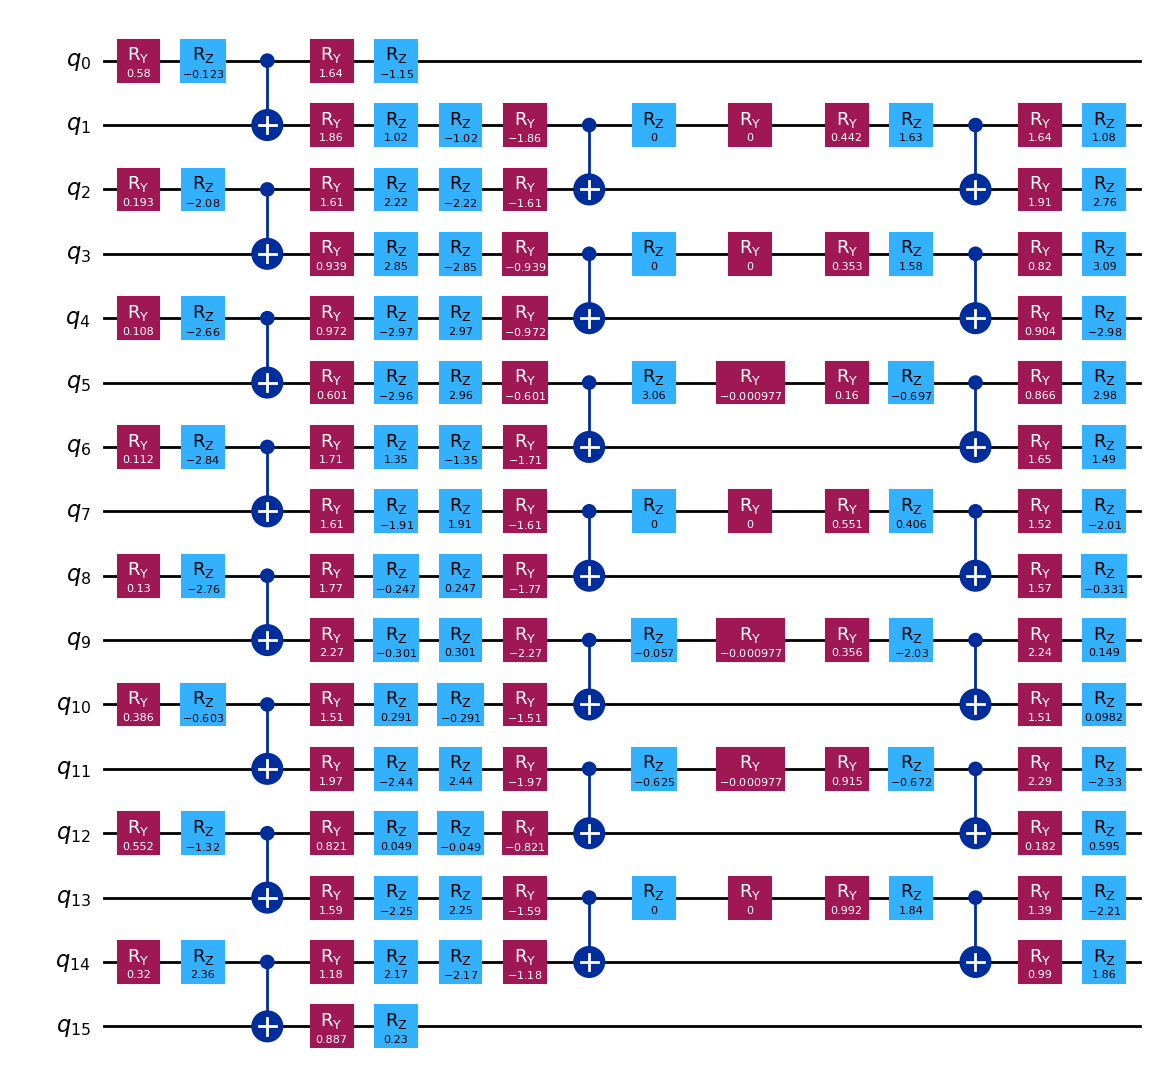

In [1023]:
U_gen.draw(output="mpl")